Moduliin import

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Data read

In [ ]:
data = pd.read_csv('../data/newrec/kalibrointidata.csv')

data.info()
data.describe()
data.columns
data.Timestamp = data.Timestamp / 1000
data.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6416 entries, 0 to 6415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Timestamp  6416 non-null   int64  
 1   AccX       6416 non-null   float64
 2   AccY       6416 non-null   float64
 3   AccZ       6416 non-null   float64
 4   GyroX      6416 non-null   float64
 5   GyroY      6416 non-null   float64
 6   GyroZ      6416 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 351.0 KB


,Timestamp,AccX,AccY,AccZ,GyroX,GyroY,GyroZ
0,563.725,0.57430,9.753493,0.21536,0.35,-4.55,1.26
1,563.734,0.88538,9.734350,0.47860,0.42,-4.62,1.33
2,563.743,0.90931,9.784601,0.26322,0.56,-4.55,1.19
3,563.752,0.98109,9.729565,0.43072,0.63,-4.69,1.12
4,563.761,0.52644,9.751101,0.14357,0.49,-4.48,1.12
5,563.770,0.78966,9.748708,0.35894,0.42,-4.55,1.19
6,563.779,0.40679,9.746315,0.47860,0.49,-4.48,1.19
7,563.788,0.71787,9.724778,0.23930,0.63,-4.55,1.19
8,563.806,0.71787,9.734350,0.23929,0.70,-4.62,1.12
9,563.816,0.59823,9.775029,0.95720,0.63,-4.62,1.12


Acc data

In [100]:
acc_data = data[['Timestamp', 'AccX', 'AccY', 'AccZ']]
acc_data.head()


,Timestamp,AccX,AccY,AccZ
0,563.725,0.57430,9.753493,0.21536
1,563.734,0.88538,9.734350,0.47860
2,563.743,0.90931,9.784601,0.26322
3,563.752,0.98109,9.729565,0.43072
4,563.761,0.52644,9.751101,0.14357


Acc plots

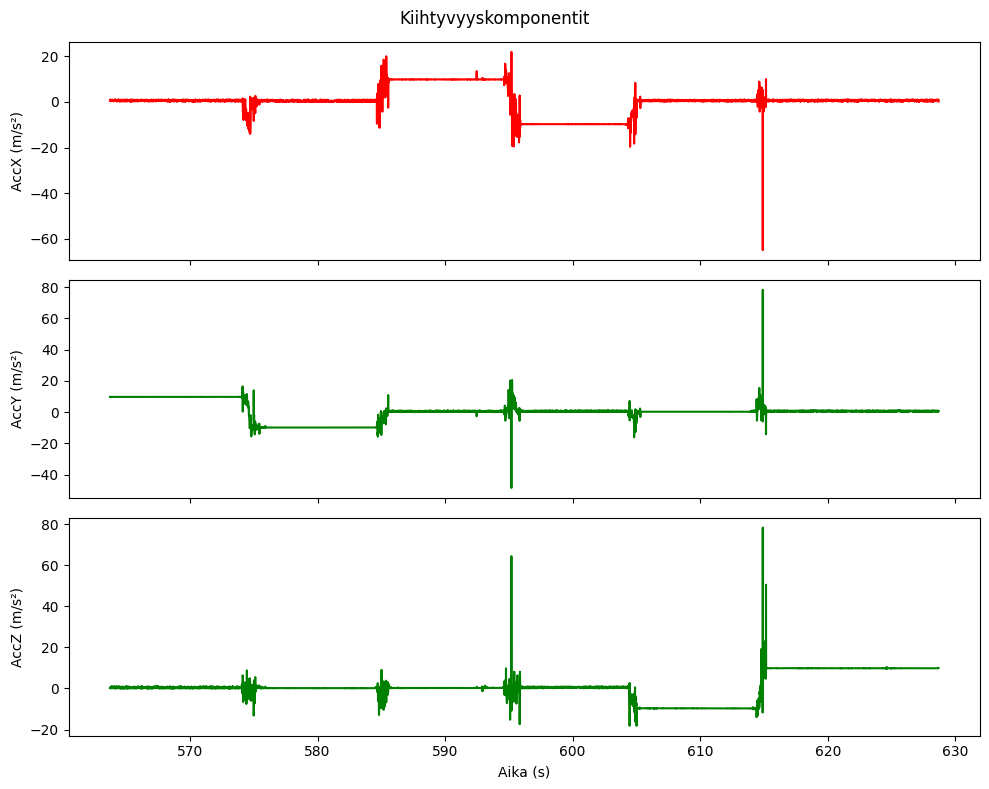

In [101]:
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axs[0].plot(acc_data['Timestamp'], acc_data['AccX'], color='r')
axs[0].set_ylabel('AccX (m/s²)')

axs[1].plot(acc_data['Timestamp'], acc_data['AccY'], color='g')
axs[1].set_ylabel('AccY (m/s²)')

axs[2].plot(acc_data['Timestamp'], acc_data['AccZ'], color='g')
axs[2].set_ylabel('AccZ (m/s²)')
axs[2].set_xlabel('Aika (s)')

plt.suptitle('Kiihtyvyyskomponentit')
plt.tight_layout()
plt.show()

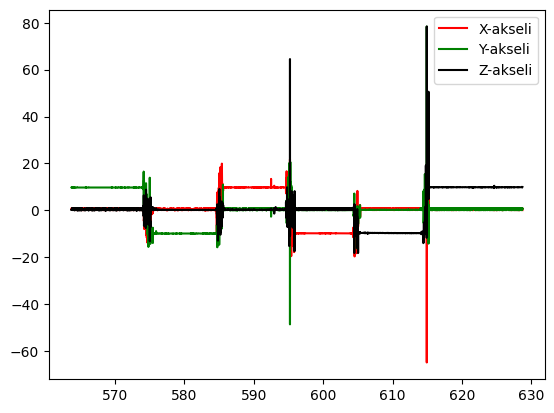

In [102]:
plt.plot(acc_data['Timestamp'], acc_data['AccX'], color='r', label='X-akseli')
plt.plot(acc_data['Timestamp'], acc_data['AccY'], color='g', label='Y-akseli')
plt.plot(acc_data['Timestamp'], acc_data['AccZ'], color='black', label='Z-akseli')
plt.legend()
plt.show()

Datan keruu

In [174]:
import importlib.util

if importlib.util.find_spec('nest_asyncio') is None:
    print('Installing nest_asnycio')
    %pip install nest_asyncio
if importlib.util.find_spec('bleak') is None:
    print('Installing bleak')
    %pip install bleak

import nest_asyncio
nest_asyncio.apply()

import asyncio
import movesense as ms
import matplotlib.pyplot as plt



# DEVICE SETTINGS

ADDRESS = "0C:8C:DC:3C:9D:19" # Movesense address

# SUBSCRIBTION SETTINGS
# Refer to API for samplerates
# https://movesense.com/docs/esw/api_reference

SENSOR = ms.Sensor.IMU9

SAMPLERATE = 104 # Depends on sensor

REC_LENGTH = 20 # In seconds

START_DELAY = 5 # Wait N seconds after connecting

FILEPATH = "../data/movesense/calib" # CSV save location (FOLDER MUST EXIST)

SAVE_TO_CSV = True # Option to disable saving data to a CSV.


device = ms.MovesenseClient(ADDRESS)

async def main():
    async with device as client:
        record = await client.subscribe(
            sensor=SENSOR, 
            samplerate=SAMPLERATE, 
            rec_length=REC_LENGTH, 
            start_delay=START_DELAY, 
            filepath=FILEPATH,
            save_to_csv=True
        )
    
        df = record.to_pandas()
        print(df.tail(5))
    
asyncio.run(main())

(ms1465) Connected
(ms1465) Recording starts in 5 seconds
(ms1465) Recording imu9 @ 104Hz
(ms1465) Recording complete
File created at: ../data/movesense/calib/ms1465_imu9_2025-11-11_09-24-17.csv
      Timestamp   AccX   AccY   AccZ  GyroX  GyroY  GyroZ  MagnX  MagnY  MagnZ
2075        NaN -0.203  9.505  2.881 -0.136  9.457  2.599   8.68   0.56   0.14
2076    51177.0 -0.452  9.246  2.836  0.258  9.474  3.168   0.00   4.83  -0.56
2077        NaN -0.108  9.354  2.278  0.211  9.722  3.116   9.94   0.07   2.52
2078        NaN -0.057  9.564  2.529  0.122  9.777  3.144  12.60   5.60   4.13
2079        NaN  0.249  9.296  2.998  0.103  9.287  3.130  11.83   8.61   4.13
(ms1465) Disconnected


Datan prekäsittely

In [175]:
oma_data = pd.read_csv('../data/movesense/calib/3-akselin_fourth_try.csv')

oma_data['Timestamp'] = oma_data['Timestamp'] /1000
oma_data['Timestamp'] = oma_data['Timestamp'].ffill()
oma_data = oma_data.set_index('Timestamp')
oma_data.describe()
oma_data.columns
oma_data.head(10)

,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,MagnX,MagnY,MagnZ
Timestamp,,,,,,,,,
0.000,0.790,9.734,1.744,0.852,9.742,1.634,3.85,1.26,6.58
0.000,0.964,9.866,1.551,0.926,9.742,1.632,5.04,-2.59,6.51
0.000,0.888,9.876,1.606,0.893,9.703,1.644,3.64,-3.71,6.30
0.000,0.914,9.859,1.620,1.046,9.660,1.663,2.45,-5.53,5.32
0.076,1.122,9.753,1.625,1.235,9.883,1.747,1.75,-6.02,-1.26
0.076,1.125,9.765,1.673,1.125,9.820,1.778,1.54,-3.57,-2.80
0.076,1.163,9.670,1.653,1.065,9.842,1.685,2.59,-0.98,-2.73
0.076,1.254,9.782,1.642,0.986,9.816,1.780,3.92,1.40,-1.47
0.152,1.022,9.710,1.780,0.943,9.742,1.505,-0.84,0.21,4.41


Datan akselin pätkiä

"oma_acc_data.iloc[:710].plot(\n    y = ['AccX'],\n    grid = True,\n    title = 'Kiihtyvyys X-akselilla',\n    xlabel = 'Aika (s)',\n    ylabel = 'Kiihtyvyys (m/s^2)'\n)\n\noma_acc_data.iloc[550:1370].plot(\n    y = ['AccY'],\n    grid = True,\n    title = 'Kiihtyvyys Y-akselilla',\n    xlabel = 'Aika (s)',\n    ylabel = 'Kiihtyvyys (m/s^2)'\n)\n\noma_acc_data.iloc[1100:2000].plot(\n    y = ['AccZ'],\n    grid = True,\n    title = 'Kiihtyvyys Z-akselilla',\n    xlabel = 'Aika (s)',\n    ylabel = 'Kiihtyvyys (m/s^2)'\n)"

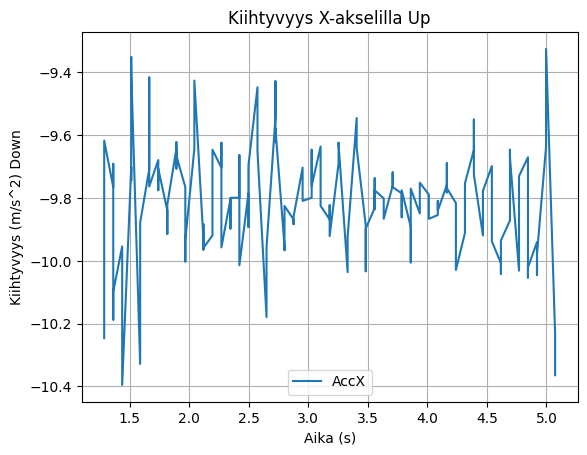

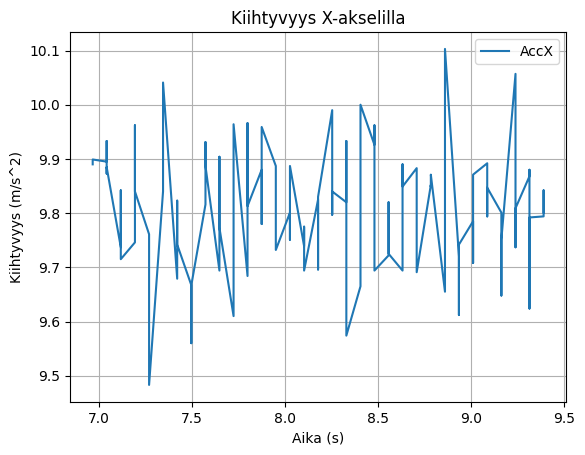

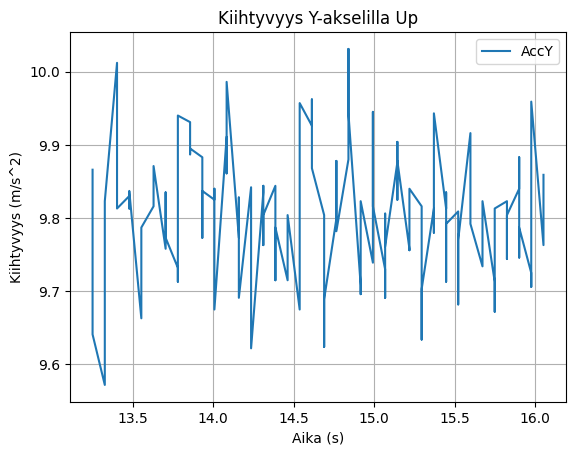

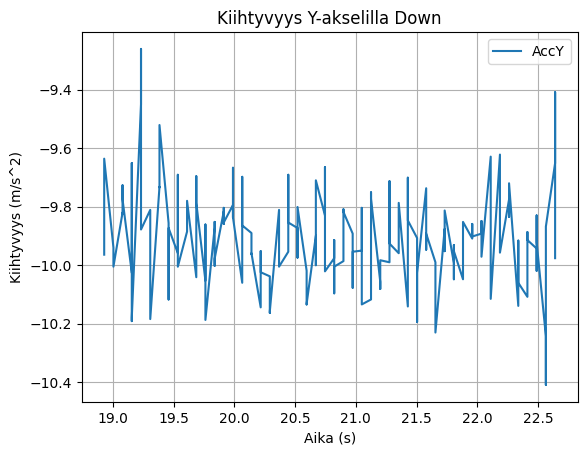

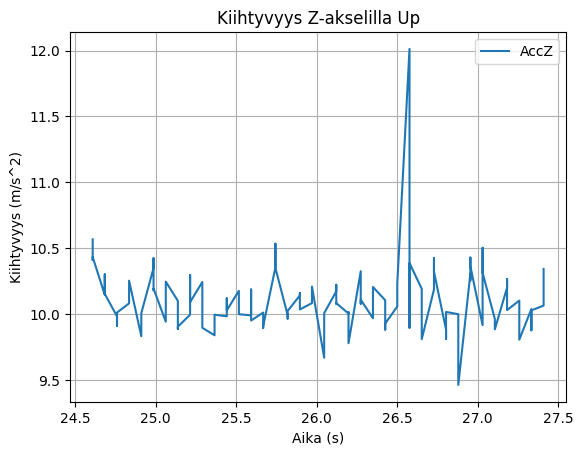

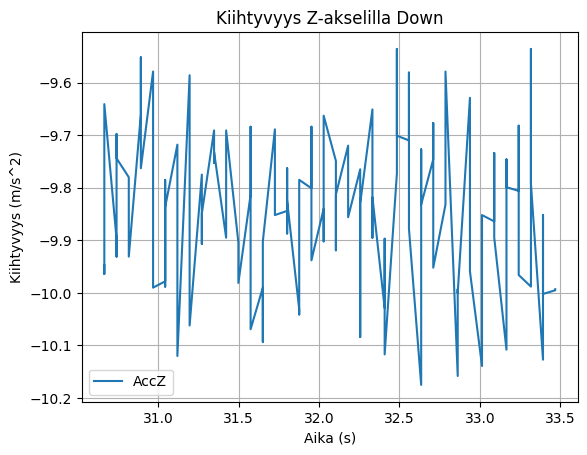

In [ ]:
oma_acc_data = oma_data[['AccX', 'AccY', 'AccZ']]



oma_acc_data.iloc[70:270].plot(
    y = ['AccX'],
    grid = True,
    title = 'Kiihtyvyys X-akselilla Up',
    xlabel = 'Aika (s)',
    ylabel = 'Kiihtyvyys (m/s^2) Down'
)

oma_acc_data.iloc[370:500].plot(
    y = ['AccX'],
    grid = True,
    title = 'Kiihtyvyys X-akselilla',
    xlabel = 'Aika (s)',
    ylabel = 'Kiihtyvyys (m/s^2)'
)

oma_acc_data.iloc[700:850].plot(
    y = ['AccY'],
    grid = True,
    title = 'Kiihtyvyys Y-akselilla Up',
    xlabel = 'Aika (s)',
    ylabel = 'Kiihtyvyys (m/s^2)'
)

oma_acc_data.iloc[1000:1200].plot(
    y = ['AccY'],
    grid = True,
    title = 'Kiihtyvyys Y-akselilla Down',
    xlabel = 'Aika (s)',
    ylabel = 'Kiihtyvyys (m/s^2)'
)

oma_acc_data.iloc[1300:1450].plot(
    y = ['AccZ'],
    grid = True,
    title = 'Kiihtyvyys Z-akselilla Up',
    xlabel = 'Aika (s)',
    ylabel = 'Kiihtyvyys (m/s^2)'
)

oma_acc_data.iloc[1620:1770].plot(
    y = ['AccZ'],
    grid = True,
    title = 'Kiihtyvyys Z-akselilla Down',
    xlabel = 'Aika (s)',
    ylabel = 'Kiihtyvyys (m/s^2)'
)



mean ja std akselin pätkistä

In [227]:
obj = {}

#X
obj['X_mean_up'] = oma_acc_data.iloc[70:270]['AccX'].mean()
obj['X_std_up'] = oma_acc_data.iloc[70:270]['AccX'].std()

obj['X_mean_down'] = oma_acc_data.iloc[370:500]['AccX'].mean()
obj['X_std_down'] = oma_acc_data.iloc[370:500]['AccX'].std()

#Y
obj['Y_mean_up'] = oma_acc_data.iloc[700:850]['AccY'].mean()
obj['Y_std_up'] = oma_acc_data.iloc[700:850]['AccY'].std()

obj['Y_mean_down'] = oma_acc_data.iloc[1000:1200]['AccY'].mean()
obj['Y_std_down'] = oma_acc_data.iloc[1000:1200]['AccY'].std()

#Z
obj['Z_mean_up'] = oma_acc_data.iloc[1300:1450]['AccZ'].mean()
obj['Z_std_up'] = oma_acc_data.iloc[1300:1450]['AccZ'].std()

obj['Z_mean_down'] = oma_acc_data.iloc[1620:1770]['AccZ'].mean()
obj['Z_std_down'] = oma_acc_data.iloc[1620:1770]['AccZ'].std()

for key, value in obj.items():
    print(key, value)









X_mean_up -9.81247
X_std_up 0.1823918943253178
X_mean_down 9.801761538461541
X_std_down 0.10855740480109898
Y_mean_up 9.804153333333334
Y_std_up 0.08610168303249988
Y_mean_down -9.913215000000001
Y_std_down 0.15972192788165054
Z_mean_up 10.098386666666665
Z_std_up 0.24564381336094265
Z_mean_down -9.843006666666668
Z_std_down 0.14212110804250866


🧠 Tulkinta

Kaikki kolme akselia mittaavat painovoiman kiihtyvyyden hyvin tarkasti.
Arvot ovat ±9.8–10.1 m/s², mikä vastaa odotettua teoreettista arvoa (9.81 m/s²).

Mittausten keskihajonta (0.08–0.25 m/s²) on pieni → mittausdata on vakaa eikä sisällä merkittävää kohinaa.

Z-akselin "Up" on hieman yli 9.8 m/s², todennäköisesti pieni kulmavirhe anturin asennossa (n. 3°), mutta se on edelleen hyväksyttävissä.

⚙️ Johtopäätös

MoveSense-anturilla suoritettu kalibrointimittaus osoitti, että kaikki kiihtyvyysakselit mittaavat oikein painovoiman vaikutuksen suunnasta riippumatta. Anturi ei vaadi lisäkalibrointia. Mittausten keskihajonta osoittaa datan vakauden ja mittauksen toistettavuuden. Näitä tuloksia voidaan käyttää jatkossa liikeanalyysin ja asennon tunnistuksen pohjana.